In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# =========================================
# STEP 2 : CHECK FOLDERS
# =========================================

import os

print(os.listdir('/content/drive/MyDrive/DL//datasets/skin disease/Split_smol/train'))

['Benign keratosis', 'Dermatofibroma', 'Tinea Ringworm Candidiasis', 'Vascular lesion', 'Squamous cell carcinoma', 'Melanocytic nevus', 'Actinic keratosis', 'Atopic Dermatitis', 'Melanoma']


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50


In [ ]:
# =========================================
# STEP 3 : DATASET PATH
# =========================================

train_path = "/content/drive/MyDrive/DL/datasets/skin disease/Split_smol/train"

val_path = "/content/drive/MyDrive/DL/datasets/skin disease/Split_smol/val"

In [ ]:
# STEP 4 : IMAGE PREPROCESSING

img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
# STEP 5 : LOAD TRAINING DATA

train_data = datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 558 images belonging to 9 classes.


In [ ]:
# STEP 6 : LOAD VALIDATION DATA

val_data = datagen.flow_from_directory(
    val_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 36 images belonging to 9 classes.


In [ ]:
# STEP 7 : CHECK CLASSES

print(train_data.class_indices)

{'Actinic keratosis': 0, 'Atopic Dermatitis': 1, 'Benign keratosis': 2, 'Dermatofibroma': 3, 'Melanocytic nevus': 4, 'Melanoma': 5, 'Squamous cell carcinoma': 6, 'Tinea Ringworm Candidiasis': 7, 'Vascular lesion': 8}


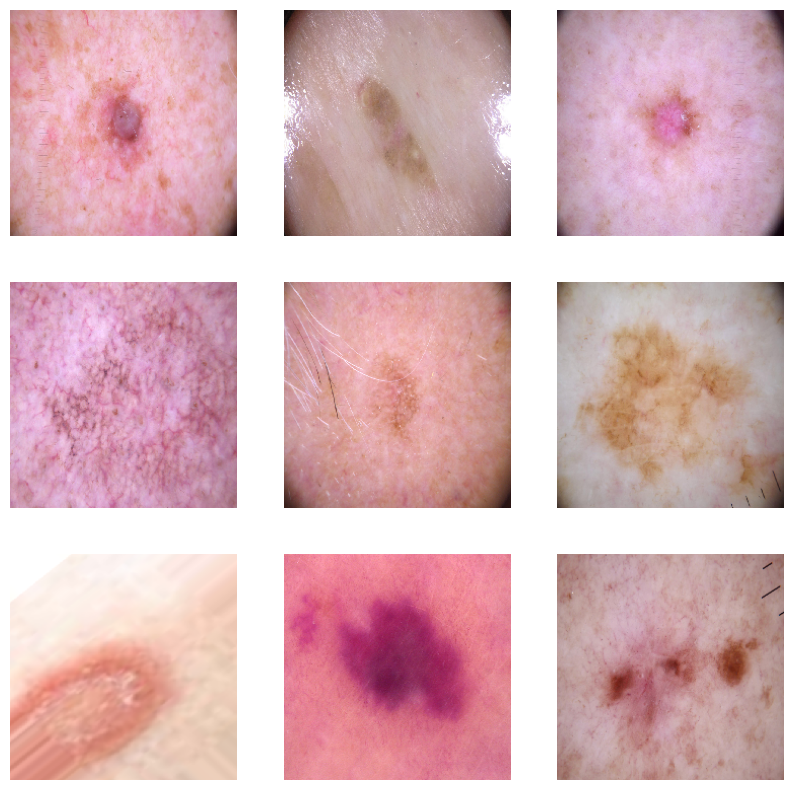

In [ ]:
# STEP 8 : DISPLAY IMAGES

plt.figure(figsize=(10,10))

images, labels = next(train_data)

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn_model = Sequential([

    Input(shape=(224,224,3)),

    Conv2D(32, (3,3), activation='relu'),

    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(train_data.num_classes,
          activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,121 (42.61 MB)

 Trainable params: 11,170,121 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 363s 20s/step - accuracy: 0.1631 - loss: 2.5855 - val_accuracy: 0.1667 - val_loss: 2.0505
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.2688 - loss: 1.9128 - val_accuracy: 0.2500 - val_loss: 1.9803
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 72s 4s/step - accuracy: 0.3315 - loss: 1.8008 - val_accuracy: 0.4722 - val_loss: 1.8822
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.3853 - loss: 1.6320 - val_accuracy: 0.5278 - val_loss: 1.6747
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.4677 - loss: 1.4508 - val_accuracy: 0.5833 - val_loss: 1.4613


In [ ]:
# =========================================
# MODEL 2 : MOBILENETV2
# =========================================

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False


mobile_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(train_data.num_classes,
          activation='softmax')
])


mobile_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_mobile = mobile_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.2401 - loss: 2.0973 - val_accuracy: 0.6111 - val_loss: 1.2824
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.5699 - loss: 1.2529 - val_accuracy: 0.7500 - val_loss: 0.8495
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.6398 - loss: 1.0622 - val_accuracy: 0.7500 - val_loss: 0.7445
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.6792 - loss: 0.8943 - val_accuracy: 0.7778 - val_loss: 0.7067
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.7366 - loss: 0.7688 - val_accuracy: 0.8056 - val_loss: 0.6342


In [ ]:
# =========================================
# MODEL 3 : RESNET50
# =========================================

base_model2 = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model2.trainable = False


resnet_model = Sequential([

    base_model2,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(train_data.num_classes,
          activation='softmax')
])


resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 129s 7s/step - accuracy: 0.0950 - loss: 2.3998 - val_accuracy: 0.1111 - val_loss: 2.2527
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 119s 7s/step - accuracy: 0.1219 - loss: 2.2532 - val_accuracy: 0.1111 - val_loss: 2.2010
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 114s 6s/step - accuracy: 0.1129 - loss: 2.2022 - val_accuracy: 0.1111 - val_loss: 2.1974
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 127s 7s/step - accuracy: 0.1183 - loss: 2.1983 - val_accuracy: 0.0833 - val_loss: 2.1983
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 121s 7s/step - accuracy: 0.1201 - loss: 2.1962 - val_accuracy: 0.1111 - val_loss: 2.1978


In [ ]:
# =========================================
# STEP 9 : MODEL ACCURACY
# =========================================

cnn_acc = max(history_cnn.history['val_accuracy'])

mobile_acc = max(history_mobile.history['val_accuracy'])

resnet_acc = max(history_resnet.history['val_accuracy'])

print("CNN Accuracy :", cnn_acc)

print("MobileNetV2 Accuracy :", mobile_acc)

print("ResNet50 Accuracy :", resnet_acc)



CNN Accuracy : 0.5833333134651184
MobileNetV2 Accuracy : 0.8055555820465088
ResNet50 Accuracy : 0.1111111119389534


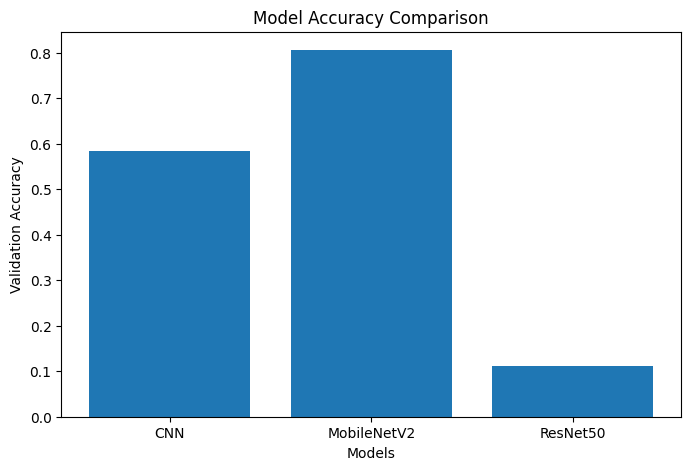

In [ ]:
# =========================================
# STEP 10 : COMPARE MODELS
# =========================================

models = ['CNN', 'MobileNetV2', 'ResNet50']

accuracy = [cnn_acc, mobile_acc, resnet_acc]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Validation Accuracy")

plt.show()




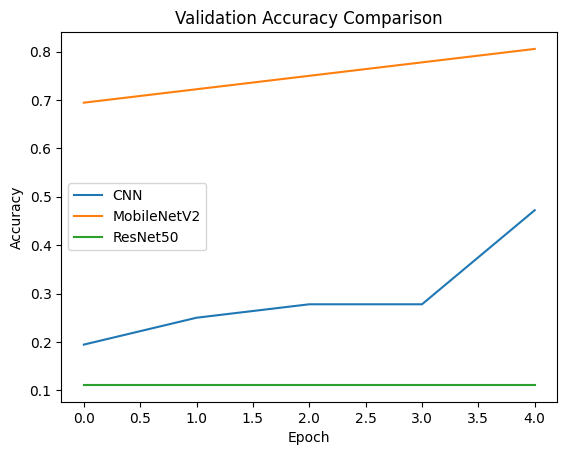

In [ ]:
# =========================================
# STEP 11 : ACCURACY CURVES
# =========================================

plt.plot(history_cnn.history['val_accuracy'])

plt.plot(history_mobile.history['val_accuracy'])

plt.plot(history_resnet.history['val_accuracy'])

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    'CNN',
    'MobileNetV2',
    'ResNet50'
])

plt.show()


In [ ]:
# =========================================
# STEP 12 : SAVE BEST MODEL
# =========================================

mobile_model.save("skin_disease_model.h5")



In [ ]:
# =========================================
# STEP 13 : UPLOAD TEST IMAGE
# =========================================

from google.colab import files

uploaded = files.upload()


In [ ]:
from tensorflow.keras.preprocessing import image

img_path = "/content/download.jpeg"

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

print(img)

In [ ]:
# =========================================
# STEP 15 : PREDICTION
# =========================================

prediction = mobile_model.predict(img_array)

predicted_class = np.argmax(prediction)

class_names = list(train_data.class_indices.keys())

print("Predicted Disease :",
      class_names[predicted_class])


In [ ]:
# =========================================
# STEP 16 : SHOW TEST IMAGE
# =========================================

plt.imshow(img)

plt.title(
    class_names[predicted_class]
)

plt.axis("off")

plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the image path
img_path = "/content/skin.jpeg"

# 2. Process the image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 3. Predict and get the label
prediction = mobile_model.predict(img_array)
class_names = list(train_data.class_indices.keys())
result = class_names[np.argmax(prediction)]

# 4. Show the result
print(f"Result: {result}")
plt.imshow(img)
plt.title(result)
plt.axis("off")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Grab one batch of images and labels from your data
images, labels = next(iter(train_data))

# 2. Pick the first image from that batch
sample_img = images[0]
sample_label = labels[0]

# 3. Predict
prediction = mobile_model.predict(sample_img[None, ...])
class_names = list(train_data.class_indices.keys())

predicted_text = class_names[np.argmax(prediction)]
actual_text = class_names[np.argmax(sample_label)]

# 4. Show result
print(f"Actual: {actual_text} | Predicted: {predicted_text}")
plt.imshow(sample_img)
plt.title(f"Target: {actual_text}\nPred: {predicted_text}")
plt.axis("off")
plt.show()

In [ ]:
# =========================================
# GRADIO FRONTEND — Skin Disease Detector
# Run this cell AFTER training the model
# =========================================

!pip install gradio -q

import gradio as gr
import numpy as np
from PIL import Image

# Class names from your training data
class_names = list(train_data.class_indices.keys())

def predict_disease(img):
    if img is None:
        return {}
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    predictions = mobile_model.predict(img_array, verbose=0)[0]
    result = {class_names[i].replace('_', ' ').title(): float(predictions[i]) for i in range(len(class_names))}
    return result

custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&family=Playfair+Display:wght@700&display=swap');

* { box-sizing: border-box; }

body, .gradio-container {
    background: #060910 !important;
    font-family: 'Inter', sans-serif !important;
}

.gradio-container {
    max-width: 860px !important;
    margin: 0 auto !important;
    padding: 0 16px 40px !important;
}

/* ── Header ── */
#app-header {
    text-align: center;
    padding: 48px 0 36px;
}
#app-header .pill {
    display: inline-flex;
    align-items: center;
    gap: 6px;
    background: rgba(56,132,255,0.12);
    border: 1px solid rgba(56,132,255,0.25);
    color: #60a5fa;
    font-size: 11px;
    font-weight: 600;
    letter-spacing: 1.2px;
    text-transform: uppercase;
    padding: 5px 14px;
    border-radius: 100px;
    margin-bottom: 18px;
}
#app-header h1 {
    font-family: 'Playfair Display', serif !important;
    font-size: 2.6rem !important;
    font-weight: 700 !important;
    color: #f1f5f9 !important;
    margin: 0 0 12px !important;
    letter-spacing: -0.5px;
    line-height: 1.15;
}
#app-header h1 span { color: #3b82f6; }
#app-header p {
    color: #64748b;
    font-size: 0.95rem;
    margin: 0;
    font-weight: 400;
}

/* ── Cards ── */
.card {
    background: #0d1117;
    border: 1px solid #1a2235;
    border-radius: 18px;
    padding: 24px;
    position: relative;
    overflow: hidden;
}
.card::before {
    content: '';
    position: absolute;
    top: 0; left: 0; right: 0;
    height: 2px;
    background: linear-gradient(90deg, transparent, #3b82f6, transparent);
    opacity: 0.6;
}
.card-label {
    font-size: 10px;
    font-weight: 700;
    letter-spacing: 1.5px;
    text-transform: uppercase;
    color: #334155;
    margin-bottom: 16px;
}

/* ── Gradio image component ── */
.gradio-image, [data-testid="image"] {
    border-radius: 12px !important;
    border: 1px solid #1a2235 !important;
    background: #080c12 !important;
    overflow: hidden !important;
}
.gradio-image label, [data-testid="image"] label {
    display: none !important;
}

/* ── Button ── */
#analyse-btn {
    margin-top: 14px;
}
#analyse-btn button {
    width: 100% !important;
    background: linear-gradient(135deg, #1d4ed8 0%, #2563eb 50%, #3b82f6 100%) !important;
    border: none !important;
    border-radius: 12px !important;
    color: white !important;
    font-family: 'Inter', sans-serif !important;
    font-size: 15px !important;
    font-weight: 600 !important;
    letter-spacing: 0.3px !important;
    padding: 14px !important;
    cursor: pointer !important;
    transition: all 0.2s ease !important;
    box-shadow: 0 4px 24px rgba(59,130,246,0.3) !important;
}
#analyse-btn button:hover {
    transform: translateY(-1px) !important;
    box-shadow: 0 6px 32px rgba(59,130,246,0.45) !important;
}

/* ── Label / results component ── */
.gradio-label, [data-testid="label"] {
    background: transparent !important;
    border: none !important;
    padding: 0 !important;
}
.gradio-label .label-wrap span,
[data-testid="label"] .label-wrap span {
    font-family: 'Playfair Display', serif !important;
    font-size: 1.6rem !important;
    font-weight: 700 !important;
    color: #60a5fa !important;
}
.gradio-label .confidence-set .bar,
[data-testid="label"] .confidence-set .bar {
    background: linear-gradient(90deg, #1d4ed8, #60a5fa) !important;
    border-radius: 4px !important;
    height: 7px !important;
}
.gradio-label .confidence-set,
[data-testid="label"] .confidence-set {
    background: #0d1117 !important;
    border: 1px solid #1a2235 !important;
    border-radius: 10px !important;
    padding: 10px 14px !important;
    margin-bottom: 7px !important;
}
.gradio-label .confidence-set .label,
[data-testid="label"] .confidence-set .label {
    color: #94a3b8 !important;
    font-size: 13px !important;
    font-weight: 500 !important;
}
.gradio-label .confidence-set .confidence,
[data-testid="label"] .confidence-set .confidence {
    color: #60a5fa !important;
    font-weight: 600 !important;
    font-size: 13px !important;
}

/* ── Disclaimer ── */
#disclaimer {
    text-align: center;
    margin-top: 28px;
    padding: 14px 20px;
    background: rgba(245,158,11,0.06);
    border: 1px solid rgba(245,158,11,0.15);
    border-radius: 10px;
    color: #78716c;
    font-size: 12px;
    line-height: 1.6;
}
#disclaimer strong { color: #f59e0b; }

/* ── Row gap ── */
.gap { gap: 20px !important; }
"""

with gr.Blocks(
    title="Skin Disease Detector",
    css=custom_css
) as demo:

    # Header
    gr.HTML("""
    <div id="app-header">
      <div class="pill">🧬 Deep Learning &nbsp;·&nbsp; MobileNetV2</div>
      <h1>Skin Disease <span>Detector</span></h1>
      <p>Upload a dermoscopic image — AI will analyse and predict the condition instantly</p>
    </div>
    """)

    # Main cards
    with gr.Row(elem_classes="gap"):

        with gr.Column():
            gr.HTML('<div class="card-label">📤 &nbsp;Input Image</div>')
            img_input = gr.Image(
                type="pil",
                label="",
                height=290,
                show_label=False
            )
            predict_btn = gr.Button(
                "✦  Analyse Image",
                elem_id="analyse-btn",
                size="lg"
            )

        with gr.Column():
            gr.HTML('<div class="card-label">📊 &nbsp;Prediction Results</div>')
            label_output = gr.Label(
                label="",
                num_top_classes=5,
                show_label=False
            )

    # Disclaimer
    gr.HTML("""
    <div id="disclaimer">
      <strong>⚠ Medical Disclaimer</strong><br>
      This tool is for <strong>educational & research purposes only</strong>.
      Always consult a qualified dermatologist for diagnosis and treatment.
    </div>
    """)

    predict_btn.click(fn=predict_disease, inputs=img_input, outputs=label_output)

demo.launch(share=True)

/tmp/ipykernel_3058/2093677903.py:197: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://79cb8c80c39d92eae4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
